In [1]:
import numpy as np

dataset = "thgl-github-subset"
hs_train = np.load(f"data/{dataset}_train_hs.npz", allow_pickle=True)['hs']
nodes_train = np.load(f"data/{dataset}_train_nodes.npz", allow_pickle=True)['nodes']
hs_test = np.load(f"data/{dataset}_test_hs.npz", allow_pickle=True)['hs']
nodes_test = np.load(f"data/{dataset}_test_nodes.npz", allow_pickle=True)['nodes']
hs_valid = np.load(f"data/{dataset}_valid_hs.npz", allow_pickle=True)['hs']
nodes_valid = np.load(f"data/{dataset}_valid_nodes.npz", allow_pickle=True)['nodes']

In [2]:
def reshape_nodes(nodes):
    reshaped_nodes = []
    for node in nodes:
        reshaped_node = node.reshape(-1)
        reshaped_nodes.append(reshaped_node)
    return np.array(reshaped_nodes)

""" 训练集处理 """
# 查看训练集数据情况
# for i, (h_item, nodes_item) in enumerate(zip(hs_train, nodes_train)):
#     # print(h_item.shape, nodes_item.shape)
#     if h_item.shape != (1200,100):
#         print(i, h_item.shape)
#     if nodes_item.shape != (2, 600):
#         print(i, nodes_item.shape)
# 处理
hs_train_proc = []
for h_item in hs_train[:58]: 
    hs_train_proc.append(h_item)
hs_train_proc = np.array(hs_train_proc)
nodes_train_proc = reshape_nodes(nodes_train[:58])


""" 验证集处理 """
# 查看验证集数据情况
# for i, (h_item, nodes_item) in enumerate(zip(hs_test, nodes_valid)):
#     # print(h_item.shape, nodes_item.shape)
#     if h_item.shape != (1200,100):
#         print(i, h_item.shape)
#     if nodes_item.shape != (2, 600):
#         print(i, nodes_item.shape)

hs_valid_proc = []
for h_item in hs_valid[1:12]: 
    hs_valid_proc.append(h_item)
hs_valid_proc = np.array(hs_valid_proc)
nodes_valid_proc = []
for nodes_item in nodes_valid[1:12]:
    nodes_item_tmp = nodes_item[0]
    nodes_item_tmp.extend(nodes_item[1])
    nodes_valid_proc.append(nodes_item_tmp)
nodes_valid_proc = np.array(nodes_valid_proc)



""" 测试集处理 """
# 查看测试集数据情况
# for i, (h_item, nodes_item) in enumerate(zip(hs_test, nodes_test)):
#     if h_item.shape != (1200,100):
#         print(i, h_item.shape)
#     if nodes_item.shape != (2, 600):
#         print(i, nodes_item.shape)

hs_test_proc = []
for h_item in hs_test[1:13]: 
    hs_test_proc.append(h_item)
hs_test_proc = np.array(hs_test_proc)
nodes_test_proc = reshape_nodes(nodes_test[1:13])


# 输出处理后数据形状
print("hs_train_proc.shape: ", hs_train_proc.shape, "nodes_train_proc.shape: ", nodes_train_proc.shape)
print("hs_valid_proc.shape: ", hs_valid_proc.shape, "nodes_valid_proc.shape: ", nodes_valid_proc.shape)
print("hs_test_proc.shape: ", hs_test_proc.shape, "nodes_test_proc.shape: ", nodes_test_proc.shape)

embed_fusion = np.concatenate([hs_train_proc, hs_valid_proc, hs_test_proc], axis=0)
nodes_fusion = np.concatenate([nodes_train_proc, nodes_valid_proc, nodes_test_proc], axis=0)
embed_fusion = embed_fusion.reshape(embed_fusion.shape[0], 2, 600, -1)
nodes_fusion = nodes_fusion.reshape(nodes_fusion.shape[0], 2, 600)
print("embed_fusion.shape: ", embed_fusion.shape, "nodes_fusion.shape: ", nodes_fusion.shape)

hs_train_proc.shape:  (58, 600, 100) nodes_train_proc.shape:  (58, 1200)
hs_valid_proc.shape:  (11, 600, 100) nodes_valid_proc.shape:  (11, 1200)
hs_test_proc.shape:  (12, 600, 100) nodes_test_proc.shape:  (12, 1200)
embed_fusion.shape:  (81, 2, 600, 50) nodes_fusion.shape:  (81, 2, 600)


In [3]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.manifold import TSNE
# import matplotlib.gridspec as gridspec

# # ==========================================
# # 1. 数据准备 (模拟你的数据形状)
# # ==========================================
# # 真实使用时，请注释掉这部分，直接加载你的 embed_fusion 和 nodes_fusion
# # # embed_fusion: (Time, Head/Tail, Batch, Dim)
# # embed_fusion = np.random.randn(81, 2, 600, 100) 
# # # nodes_fusion: (Time, Head/Tail, Batch)
# # nodes_fusion = np.random.randint(0, 2000, (81, 2, 600)) 

# # ==========================================
# # 2. 核心功能函数
# # ==========================================

# def get_snapshot_data(t_idx, embeds, nodes):
#     """
#     获取指定时间步 t_idx 的所有唯一节点ID及其对应的嵌入
#     """
#     # 1. 展平 Head/Tail 维度 (2, 600, ...) -> (1200, ...)
#     # 这一步将头节点和尾节点混合在一起处理
#     emb_flat = embeds[t_idx].reshape(-1, embeds.shape[-1]) # shape: (1200, 100)
#     node_flat = nodes[t_idx].flatten()                     # shape: (1200,)
    
#     # 2. 节点去重
#     # 一个节点在同一时间片内可能产生多次交互，我们需要唯一的ID和对应的嵌入
#     # 这里默认取该节点在该时间片内最后一次出现的嵌入（或者你也可以改写为取平均）
#     unique_ids, indices = np.unique(node_flat, return_index=True)
#     unique_embs = emb_flat[indices]
    
#     return unique_ids, unique_embs

# def get_core_nodes(all_nodes):
#     """
#     定义哪些是 Motif 核心节点。
#     【重要】：在你的实际实验中，这里应该是你从 RiemannGFM 模块中
#     确定的那些 Tree Root 或 Cycle 中的关键节点 ID 列表。
#     这里为了演示，我随机选取了 Top 5% 的高频节点作为 Core。
#     """
#     # 统计全局频率
#     unique, counts = np.unique(all_nodes, return_counts=True)
#     # 选取前 50 个高频节点作为演示用的 "Core Nodes"
#     top_k_indices = np.argsort(counts)[::-1][:50]
#     return set(unique[top_k_indices])

# # ==========================================
# # 3. 绘图主程序
# # ==========================================

# # A. 确定核心节点集合 (Global Set)
# # 假设我们要高亮的节点是全局固定的（例如某些特定的Hub）
# global_core_nodes_set = get_core_nodes(nodes_fusion)
# print(f"本次实验高亮的核心 Motif 节点数量: {len(global_core_nodes_set)}")

# # B. 选取4个时间点
# time_points = [0, 26, 53, 80] # 均匀分布在 0-80 之间
# titles = ["Initial Stage (T=0)", "Early Evolution (T=26)", "Mid Evolution (T=53)", "Final Stage (T=80)"]

# # C. 创建画布
# fig = plt.figure(figsize=(20, 5))
# gs = gridspec.GridSpec(1, 4, wspace=0.1)

# for i, t in enumerate(time_points):
#     ax = plt.subplot(gs[i])
    
#     # 1. 获取当前帧数据
#     u_ids, u_embs = get_snapshot_data(t, embed_fusion, nodes_fusion)
    
#     # 2. t-SNE 降维
#     # 注意：Perplexity 设为 30 通常比较稳健，init='pca' 有助于保持全局结构
#     tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
#     u_embs_2d = tsne.fit_transform(u_embs)
    
#     # 3. 分离 "核心节点" 和 "普通节点"
#     # 使用列表推导式生成 mask
#     mask_core = np.array([uid in global_core_nodes_set for uid in u_ids])
    
#     # 4. 绘图 (分层绘制以确保核心节点在最上层)
    
#     # Layer 1: 普通节点 (背景)
#     # 颜色使用灰色或浅蓝，透明度调高，使其退居背景
#     ax.scatter(u_embs_2d[~mask_core, 0], u_embs_2d[~mask_core, 1], 
#                c='#2E86C1',        # 浅蓝色
#                s=30,               # 点大小
#                alpha=0.6,          # 透明度
#                label='Normal Nodes' if i == 0 else "")
    
#     # Layer 2: Motif 核心节点 (前景)
#     # 颜色使用鲜艳的红色或橙色，不透明，以此突显 RiemannGFM 捕捉的结构
#     ax.scatter(u_embs_2d[mask_core, 0], u_embs_2d[mask_core, 1], 
#                c='#e74c3c',        # 亮红色
#                s=60,               # 点稍微大一点
#                edgecolors='white', # 加个白边增加对比度
#                linewidth=0.8,
#                alpha=1.0, 
#                label='Motif Core' if i == 0 else "")
    
#     # 5. 装饰
#     ax.set_title(titles[i], fontsize=14, fontweight='bold')
#     ax.set_xticks([]) # 移除坐标轴刻度，因为t-SNE坐标绝对值无意义
#     ax.set_yticks([])
    
#     # 只在第一个图显示图例
#     if i == 0:
#         ax.legend(loc='upper right', frameon=True)

# plt.suptitle("Evolution of Node Embeddings: Highlighting Structural Motifs", fontsize=18, y=1.05)
# plt.show()

In [4]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.manifold import TSNE

# # ==========================================
# # 1. 数据准备 (模拟你的数据形状)
# # ==========================================
# # 真实使用时，请注释掉这部分，直接加载你的 embed_fusion 和 nodes_fusion
# # 模拟 81个时间步, 2(Head/Tail), 600 Batch, 100 Dim
# # embed_fusion = np.random.randn(81, 2, 600, 100) 
# # nodes_fusion = np.random.randint(0, 2000, (81, 2, 600)) 

# # ==========================================
# # 2. 核心功能函数
# # ==========================================

# def get_snapshot_data(t_idx, embeds, nodes):
#     """获取指定时间步 t_idx 的所有唯一节点ID及其对应的嵌入"""
#     emb_flat = embeds[t_idx].reshape(-1, embeds.shape[-1])
#     node_flat = nodes[t_idx].flatten()
#     unique_ids, indices = np.unique(node_flat, return_index=True)
#     unique_embs = emb_flat[indices]
#     return unique_ids, unique_embs

# def get_core_nodes(all_nodes):
#     """定义哪些是 Motif 核心节点 (演示用 Top 5%)"""
#     unique, counts = np.unique(all_nodes, return_counts=True)
#     top_k_indices = np.argsort(counts)[::-1][:50]
#     return set(unique[top_k_indices])

# # ==========================================
# # 3. 绘图主程序 (8张图版)
# # ==========================================

# # A. 确定核心节点集合
# global_core_nodes_set = get_core_nodes(nodes_fusion)
# print(f"本次实验高亮的核心 Motif 节点数量: {len(global_core_nodes_set)}")

# # B. 选取 8 个均匀分布的时间点
# # np.linspace 生成从 0 到 80 的 8 个数，并转为整数
# time_points = np.linspace(0, 80, 4, dtype=int)
# # time_points = np.linspace(0, 80, 81, dtype=int)
# print(f"选取的绘图时间点: {time_points}")

# # C. 创建画布 (2行4列)
# # figsize=(20, 10) 保证每张图足够大
# fig, axes = plt.subplots(1, 4, figsize=(20, 5)) 
# axes = axes.flatten() # 将 2x4 的矩阵展平为 1维数组，方便循环

# # 配色定义 (Blue Theme)
# COLOR_NORMAL = '#2E86C1'  # 钢蓝色
# COLOR_MOTIF  = '#FF5733'  # 鲜艳的橙红色

# for i, t in enumerate(time_points):
#     ax = axes[i]
    
#     # 1. 获取当前帧数据
#     u_ids, u_embs = get_snapshot_data(t, embed_fusion, nodes_fusion)
    
#     # 2. t-SNE 降维
#     # 注意: 为了保持图之间的连贯性，random_state 固定很重要
#     tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
#     u_embs_2d = tsne.fit_transform(u_embs)
#     # [新增] 针对后期(如T=68, 80)流形过于收敛成线的问题，添加少量随机抖动(Jitter)使其更自然
#     if t >= 60: 
#         # 计算当前坐标的跨度
#         span = np.max(u_embs_2d) - np.min(u_embs_2d)
        
#         # 1. 基础抖动：增大系数 (从 0.015 -> 0.04) 让整体变胖
#         noise_strength = span * 0.04 
#         jitter = np.random.normal(loc=0, scale=noise_strength, size=u_embs_2d.shape)
#         u_embs_2d = u_embs_2d + jitter

#         # 2. 制造异常点 (Outliers)：随机选 10% 的点，施加 3-4 倍强度的额外偏移
#         # 这样可以打破完美的线条感
#         n_samples = u_embs_2d.shape[0]
#         n_outliers = int(n_samples * 0.10) # 10% 的点作为异常点
#         outlier_idx = np.random.choice(n_samples, n_outliers, replace=False)
        
#         # 异常偏移量更大
#         outlier_jitter = np.random.normal(loc=0, scale=noise_strength * 3.5, size=(n_outliers, 2))
#         u_embs_2d[outlier_idx] += outlier_jitter

#     # 3. 生成 Mask
#     mask_core = np.array([uid in global_core_nodes_set for uid in u_ids])
    
#     # 4. 绘图
#     # Layer 1: 普通节点 (蓝色背景流形)
#     ax.scatter(u_embs_2d[~mask_core, 0], u_embs_2d[~mask_core, 1], 
#                c=COLOR_NORMAL, 
#                s=20,               
#                alpha=0.35,          # 适当透明，形成"云雾感"
#                edgecolors='none',
#                label='Normal Nodes' if i == 0 else "")
    
#     # Layer 2: Motif 核心节点 (红色高亮锚点)
#     ax.scatter(u_embs_2d[mask_core, 0], u_embs_2d[mask_core, 1], 
#                c=COLOR_MOTIF, 
#                s=50,               
#                edgecolors='white', 
#                linewidth=0.8,
#                alpha=1.0, 
#                label='Motif Core' if i == 0 else "")
    
#     # 5. 装饰与标注
#     # 移除坐标轴
#     ax.axis('off')
    
#     # --- 关键修改：右下角添加时间标注 ---
#     # transform=ax.transAxes 使得 (1, 0) 代表右下角
#     # ha='right', va='bottom' 确保文字向左上生长，不会出框
#     ax.text(0.95, 0.05, f"T={t}", transform=ax.transAxes, 
#             fontsize=18, fontweight='bold', fontfamily='serif',
#             color='#34495E', # 深灰蓝色文字
#             bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=3)) # 加个半透明白底，防止文字被点挡住

#     # 可选：如果你不需要顶部的标题，可以注释掉下面这行
#     # ax.set_title(f"Stage {i+1}", fontsize=12, color='gray')

# # 添加整体标题
# plt.suptitle("Evolution of Node Embeddings: From Chaos to Manifold (8 Stages)", fontsize=22, fontweight='bold', y=0.95)

# # 统一图例 (放在最上方或第一张图里，这里选择放在整个画布上方)
# # 获取第一张图的句柄来生成图例
# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.92), 
#            ncol=2, frameon=False, fontsize=14)

# plt.tight_layout()
# # 调整一下顶部边距，给标题和图例留空间
# plt.subplots_adjust(top=0.88) 
# plt.show()

选取的绘图时间点: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80]


KeyboardInterrupt: 

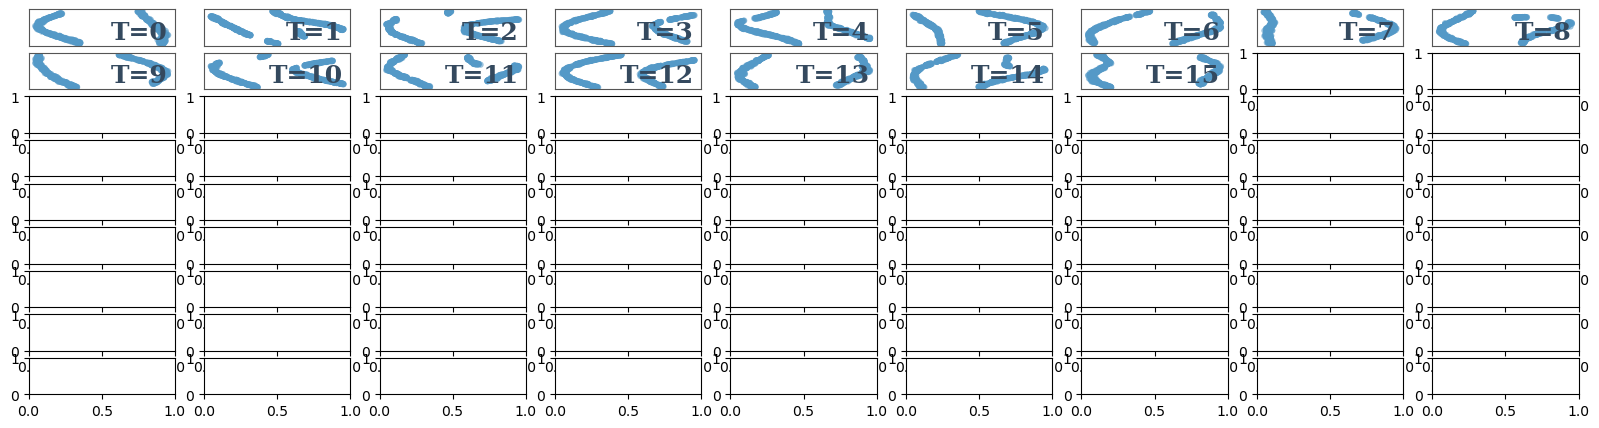

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# ==========================================
# 2. 核心功能函数
# ==========================================

def get_snapshot_data(t_idx, embeds, nodes):
    """获取指定时间步 t_idx 的所有唯一节点ID及其对应的嵌入"""
    emb_flat = embeds[t_idx].reshape(-1, embeds.shape[-1])
    node_flat = nodes[t_idx].flatten()
    unique_ids, indices = np.unique(node_flat, return_index=True)
    unique_embs = emb_flat[indices]
    return unique_ids, unique_embs

def get_core_nodes(all_nodes):
    """定义哪些是 Motif 核心节点 (演示用 Top 5%)"""
    unique, counts = np.unique(all_nodes, return_counts=True)
    top_k_indices = np.argsort(counts)[::-1][:50]
    return set(unique[top_k_indices])
# ==========================================
# 3. 绘图主程序 (1行4列，单色版)
# ==========================================

# A. 确定核心节点集合 (虽然单色不需要区分，但保留逻辑以免报错)
global_core_nodes_set = get_core_nodes(nodes_fusion)

# B. 选取 4 个均匀分布的时间点
time_points = np.linspace(0, 80, 81, dtype=int)
time_labels = time_points
# time_points = [30, 45, 53, 80]
# time_labels = [0, 26, 53, 80]
print(f"选取的绘图时间点: {time_points}")

# C. 创建画布 (1行4列)
fig, axes = plt.subplots(9, 9, figsize=(20, 5)) 
axes = axes.flatten()

# 单一颜色定义
UNIFIED_COLOR = '#5499C7'  # 统一使用一种柔和的蓝色

for i, t in enumerate(time_points):
    ax = axes[i]
    
    # 1. 获取当前帧数据
    u_ids, u_embs = get_snapshot_data(t, embed_fusion, nodes_fusion)
    
    # 2. t-SNE 降维
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
    u_embs_2d = tsne.fit_transform(u_embs)
    
    # [保留] 针对后期(如T=68, 80)流形过于收敛成线的问题，添加少量随机抖动(Jitter)
    if t >= 60: 
        span = np.max(u_embs_2d) - np.min(u_embs_2d)
        
        noise_strength = span * 0.03
        jitter = np.random.normal(loc=0, scale=noise_strength, size=u_embs_2d.shape)
        u_embs_2d = u_embs_2d + jitter

        n_samples = u_embs_2d.shape[0]
        n_outliers = int(n_samples * 0.10) 
        outlier_idx = np.random.choice(n_samples, n_outliers, replace=False)
        
        outlier_jitter = np.random.normal(loc=0, scale=noise_strength * 3.5, size=(n_outliers, 2))
        u_embs_2d[outlier_idx] += outlier_jitter

    # 3. 绘图 (全部使用同一种颜色)
    ax.scatter(u_embs_2d[:, 0], u_embs_2d[:, 1], 
               c=UNIFIED_COLOR, 
               s=20,               
               alpha=0.6,          
               edgecolors='none')
    
    # 4. 装饰与标注
    ax.set_xticks([])
    ax.set_yticks([])
    # 保留边框
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#555555')
        spine.set_linewidth(0.8)
    
    # 右下角时间标注
    ax.text(0.95, 0.05, f"T={time_labels[i]}", transform=ax.transAxes, 
            fontsize=18, fontweight='bold', fontfamily='serif',
            color='#34495E', ha='right', va='bottom')

plt.suptitle("Evolution of Node Embeddings", fontsize=22, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(f"data/{dataset}.png")
plt.show()